# A tabulated solar model: are you computing the observable?

You have a real solar model on disk -- a table of radius, density and composition --
and you want oscillation probabilities from it. This notebook does exactly that with
**BS2005-AGS,OP** (Bahcall, Serenelli & Basu, ApJ 621, L85), and uses it to separate two
quantities that are easy to confuse:

* the **instantaneous** probability at one baseline, which is what `osc_prob_*` returns;
* the **phase-averaged** probability, which is what a solar-neutrino experiment measures.

They are different quantities, not two estimates of one quantity, and the notebook's
headline is about how you get the second.

**The tempting route does not work.** Averaging a scan of instantaneous probabilities over a
window of several oscillation lengths looks like the obvious way to reach the observable. On
a solar trajectory it is not: the answer drifts by about $10^{-2}$ depending on how wide
a window you pick, because widening the window also averages over a changing density. The
estimator has no converged value to offer.

**The direct route is exact.** `average=True` evaluates the phase-averaged limit in closed
form -- one matrix product, no scan -- and it reproduces the textbook adiabatic MSW
expression to **machine precision, 3e-16, across 1--20 MeV**, checked against a formula that
owes nothing to Mag$\nu$s.

The notebook also shows the diagnostics: `strategy_info['sampling']` for how coarsely a scan
resolves the oscillation it is sampling, and `avgprob.coherence_report` for whether the
averaged limit applies at all.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import magnus.globaldefs as gd

# Best-fit oscillation parameters from the latest global fit.
# load_nufit_params returns exactly the six parameters the
# osc_prob_3nu_* functions take, so it can be splatted straight in.
NUFIT_NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.oscprob as oscprob
import magnus.adiabatic as adiabatic

plt.rcParams["figure.dpi"] = 110

## 1. Load the model and build an electron-density profile

The table ships with the repository, under `docs/dev/adversarial_batteries/`. Two
details matter and are easy to get wrong:

* **The electron fraction is not 0.5.** For fully ionized H + He,
  $n_e = \rho\,N_A\,(1+X)/2$, and the hydrogen mass fraction $X$ runs from 0.36 at the
  centre to 0.75 at the surface. Using a fixed $Y_e = 0.5$ would be wrong by up to 70 %,
  which is why we build the number density ourselves rather than handing a mass density
  to `vcc_func_from_rho_func` (that function takes a *scalar* electron fraction).
* **Interpolate in $\log n_e$.** The density spans five orders of magnitude; a linear
  interpolant in the raw value is poor and a spline can undershoot to negative values.

In [3]:
TABLE = os.path.join('..', 'docs', 'dev', 'adversarial_batteries', 'bs05_agsop.dat')

rows = []
with open(TABLE) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                rows.append([float(x) for x in f])
            except ValueError:
                continue          # the column-heading line
table = np.array(rows)

r_over_rsun = table[:, 1]
rho_cgs, x_hydrogen = table[:, 3], table[:, 6]

# n_e = rho * N_A * (1 + X) / 2, in the package's natural units [eV^3].
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
ne_ev3 = rho_cgs*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_hydrogen))

x_nat = r_over_rsun*gd.SUN_RADIUS*gd.UNIT_KM          # radius in eV^-1
log_ne = np.log(ne_ev3)

def ne_bs05(l):
    '''Electron number density [eV^3] at position l [eV^-1], log-interpolated.'''
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(np.interp(xs, x_nat, log_ne))
    return out[()] if np.ndim(out) == 0 else out

print('%d rows, r = %.5f .. %.5f R_sun' % (len(table), r_over_rsun[0], r_over_rsun[-1]))
print('central n_e = %.1f N_A cm^-3' % (ne_ev3[0]/gd.N_AV/gd.UNIT_PER_CM3))

1284 rows, r = 0.00161 .. 0.98308 R_sun
central n_e = 101.9 N_A cm^-3


### The package's exponential is a *fit*, not this model

`gd.NUM_DENSITY_E_SUN_CENTRAL` = 245 $N_A$ is the $r\to0$ intercept of the standard
exponential fit $n_e = 245\,N_A e^{-10.54 r/R_\odot}$. The model's actual central value
is 101.9 $N_A$ (printed below). The fit is a few-percent description only in a band around
$0.2\,R_\odot$; inside $0.05\,R_\odot$ it is high by a factor 2.4.

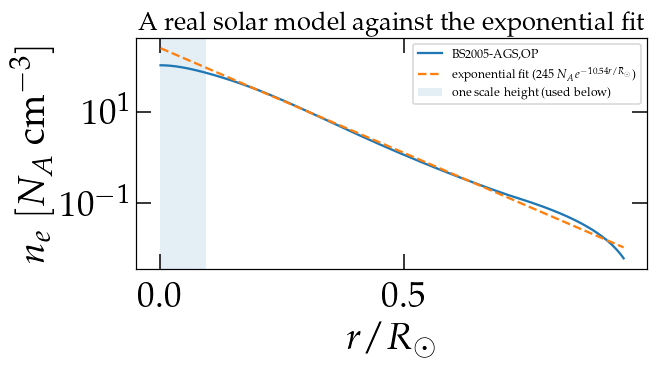

In [4]:
fit = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
rr = np.linspace(0.002, 0.95, 400)
xs = rr*gd.SUN_RADIUS*gd.UNIT_KM
ax.semilogy(rr, np.asarray(ne_bs05(xs))/gd.N_AV/gd.UNIT_PER_CM3, label='BS2005-AGS,OP')
ax.semilogy(rr, np.asarray(fit(xs))/gd.N_AV/gd.UNIT_PER_CM3, '--',
            label=r'exponential fit ($245\,N_A e^{-10.54 r/R_\odot}$)')
ax.axvspan(0.0, gd.L_SCALE_SUN/(gd.SUN_RADIUS*gd.UNIT_KM), alpha=0.12,
           label='one scale height (used below)')
ax.set_xlabel(r'$r / R_\odot$'); ax.set_ylabel(r'$n_e\ [N_A\ {\rm cm}^{-3}]$')
ax.legend(fontsize=8); ax.set_title('A real solar model against the exponential fit')
fig.tight_layout()

## 2. The instantaneous probability, and its error

We take a two-flavour calculation at **5 MeV** -- in the $^8$B range -- over one solar
scale height, and check it against a tight-tolerance `solve_ivp` ground truth.

In [5]:
def exact_U_many(H_func, l0, Ls, dim):
    '''Ground truth at many baselines from ONE integration.'''
    def rhs(l, y):
        return (-1j*np.asarray(H_func(l)) @ y.reshape(dim, dim)).ravel()
    sol = solve_ivp(rhs, (float(l0), float(Ls[-1])), np.eye(dim, dtype=complex).ravel(),
                    rtol=1e-12, atol=1e-14, method='DOP853', t_eval=Ls)
    return np.array([sol.y[:, i].reshape(dim, dim) for i in range(len(Ls))])

def to_P(U):
    return np.swapaxes(np.asarray(U).real**2 + np.asarray(U).imag**2, -1, -2)

ENERGY = 5.0*gd.UNIT_MEV
L0, L1 = 0.0, gd.L_SCALE_SUN
params2 = {'sth': NUFIT_NO['s12'], 'Dm2': NUFIT_NO['D21']}

hvac2 = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
    params2['sth'], params2['Dm2'])
e00 = np.diag([1.0, 0.0])
VCC = matter.vcc_func_from_rho_func(
    ne_bs05, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_of_l(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC(l))[..., None, None]*e00

info = {}
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    P = np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, L1, params2, L0=L0,
        density_is_of_number_of_electrons=True, strategy_info=info))
    raised = sorted({w.category.__name__ for w in caught})

P_ref = to_P(exact_U_many(H_of_l, L0, np.array([L1]), 2)[0])
print('engine        : %s' % info['engine'])
print('certified     : %s' % info.get('certified'))
print('warnings      : %s' % (', '.join(raised) or 'NONE'))
print('P_ee          : %.6f   (truth %.6f)' % (P[0][0], P_ref[0][0]))
print('max |error|   : %.3e   against a requested %.0e' % (np.max(np.abs(P - P_ref)), 1e-3))

engine        : hybrid
certified     : True
warnings      : NONE
P_ee          : 0.957850   (truth 0.957250)
max |error|   : 6.000e-04   against a requested 1e-03


That is inside the requested tolerance, reported as `certified`, with no warning --
which is the right answer, but not yet an interesting one. The interesting question is what
this number is *of*: it is the error in the probability at **one exact baseline**, and no
solar experiment measures that.

The rest of this notebook is about the quantity one does measure, and about how easy it is
to compute something that looks like it and is not.

## 3. `strategy_info['sampling']`: how much phase is in there?

`adiabatic.oscillation_sampling` reports how coarsely a request samples the oscillation
it is computing. It is surfaced through `strategy_info` and is computed **only** when you
ask for it, so it costs nothing on an ordinary call.

In [6]:
Ls_scan = np.linspace(0.2*L1, L1, 8)
info_scan = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, Ls_scan, params2, L0=L0,
        density_is_of_number_of_electrons=True, strategy_info=info_scan)

for k, v in sorted(info_scan['sampling'].items()):
    print('%-24s %s' % (k, ('%.4e' % v) if isinstance(v, float) else v))

aliased                  True
cycles_over_trajectory   4.5243e+02
cycles_per_step          5.1707e+01
nyquist_points           906
oscillation_length       7.3827e+11
spacing                  3.8174e+13


`cycles_per_step` is the number to read. It is far above 0.5, so this eight-point scan
takes **less than two samples per oscillation**: the individual values are correct, but
the curve through them is an artefact. `nyquist_points` says how many baselines you would
need to sample the oscillation properly -- about 900 here, and several thousand at the
energies and flavour counts used elsewhere in the documentation.

That is the signature of a quantity dominated by phase. A solar-neutrino experiment
resolves none of it: the $^8$B production region is extended, the Sun-Earth phase is
$\sim10^{10}$ cycles, and detector energy resolution finishes the job.

## 4. The averaged probability -- the quantity that is actually observed

A solar experiment measures the **phase-averaged** survival probability. The obvious way to
get at it is to average a scan of instantaneous probabilities over a window of several
oscillation lengths, and that is what this section does first -- because it is the natural
thing to try, it is what an earlier version of this notebook reported, and **it does not
work here.** The section after it shows the quantity that does.

In [7]:
L_OSC = 4.0*np.pi*ENERGY/params2['Dm2']         # vacuum oscillation length
Ls = np.linspace(L1 - 6.0*L_OSC, L1, 121)

P_ref_many = np.array([to_P(U) for U in exact_U_many(H_of_l, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    P_pkg = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, float(L), params2, L0=L0,
        density_is_of_number_of_electrons=True)) for L in Ls])

err_inst = np.max(np.abs(P_pkg[-1] - P_ref_many[-1]))
err_avg = np.max(np.abs(P_pkg.mean(axis=0) - P_ref_many.mean(axis=0)))

print('trajectory        : %.0f oscillation lengths' % ((L1 - L0)/L_OSC))
# The verdicts are COMPUTED, not written into the format string.  They used to be
# asserted -- '<-- outside 1e-3' was a literal -- and when the underlying numbers
# moved the cell went on printing a verdict its own output contradicted.  A label
# that cannot be wrong by construction is worth more than a tidy one.
def _verdict(err, tol=1.0e-3):
    return ('outside' if err > tol else 'inside') + ' %.0e' % tol

print('instantaneous err : %.3e   <-- %s' % (err_inst, _verdict(err_inst)))
print('AVERAGED err      : %.3e   <-- %s' % (err_avg, _verdict(err_avg)))
print('averaging changes the error by %.2fx  (%s)'
      % (err_inst/err_avg,
         'helps' if err_avg < err_inst else 'does not help here -- see below'))
print()
print('averaged P_ee: package %.6f   truth %.6f' %
      (P_pkg.mean(axis=0)[0][0], P_ref_many.mean(axis=0)[0][0]))

trajectory        : 401 oscillation lengths
instantaneous err : 6.000e-04   <-- inside 1e-03
AVERAGED err      : 7.110e-04   <-- inside 1e-03
averaging changes the error by 0.84x  (does not help here -- see below)

averaged P_ee: package 0.591719   truth 0.592430


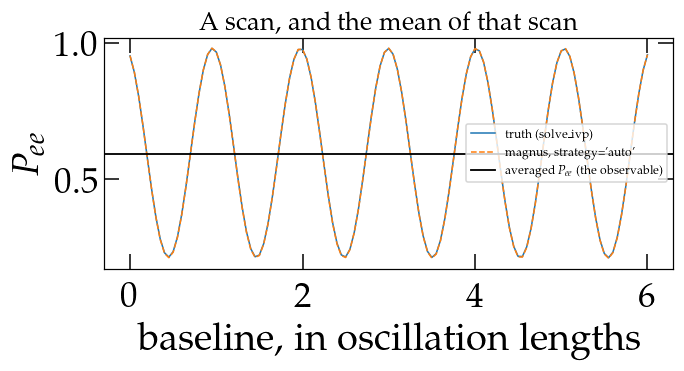

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
xs_plot = (Ls - Ls[0])/L_OSC
ax.plot(xs_plot, P_ref_many[:, 0, 0], lw=1.0, label='truth (solve_ivp)')
ax.plot(xs_plot, P_pkg[:, 0, 0], lw=1.0, ls='--', label="magnus, strategy='auto'")
ax.axhline(P_ref_many[:, 0, 0].mean(), color='k', lw=1.2,
           label='averaged $P_{ee}$ (the observable)')
ax.set_xlabel('baseline, in oscillation lengths'); ax.set_ylabel(r'$P_{ee}$')
ax.legend(fontsize=8); ax.set_title('A scan, and the mean of that scan')
fig.tight_layout()

Averaging did not help. It is worth being precise about why, because the reason is not
that the package is inaccurate -- it is that **the mean of this scan is not a converged
estimate of anything.**

Two things are wrong with it. The window is six *vacuum* oscillation lengths, but the
neutrino is in matter, so the window is not a whole number of actual cycles. And -- the
part that cannot be tuned away -- widening the window does not fix it, because a wider
window also averages over a **changing density**, and the averaged probability depends on
the local density. There is no window width that separates phase from the profile.

The truth alone shows this, no package involved: one ODE solve, several window widths.

In [9]:
# Truth only.  One integration with many output points, so this is cheap: the
# expensive thing in the cell above was one full ray propagation per baseline.
print('%-22s %s' % ('window', 'mean of the truth'))
print('-'*44)
for n_osc in (6, 12, 24, 48):
    Ls_w = np.linspace(L1 - n_osc*L_OSC, L1, 20*n_osc + 1)
    P_w = np.array([to_P(U) for U in exact_U_many(H_of_l, L0, Ls_w, 2)])
    print('%-22s %.6f' % ('%d oscillation lengths' % n_osc, P_w[:, 0, 0].mean()))

window                 mean of the truth
--------------------------------------------


6 oscillation lengths  0.592430


12 oscillation lengths 0.592685


24 oscillation lengths 0.596496


48 oscillation lengths 0.602295


The number moves and keeps moving. Widening the window makes it *worse*, not better,
which is the signature of an estimator whose bias is not statistical.

### The averaged probability, computed rather than estimated

`average=True` evaluates the phase-averaged limit in closed form -- one matrix product, no
scan, no window. And it can be checked against something outside Mag$\nu$s entirely: for two
flavours on an adiabatic trajectory the averaged survival probability is the textbook MSW
expression

$$\langle P_{ee}\rangle = \frac{1}{2}
  + \frac{1}{2}\cos 2\theta_m(L_0)\,\cos 2\theta_m(L_1),$$

with $\theta_m$ the matter mixing angle at each end. Both ends are evaluated **in matter**:
this trajectory stops one scale height in, not in vacuum, so the usual $\cos 2\theta_{\rm vac}$
at the far end would be the wrong reference. The LMA solar crossing is never sharp, which is
what makes the adiabatic form exact here rather than approximate -- notebook 12 measures that
directly.

In [10]:
TH_VAC = np.arcsin(params2['sth'])

def cos2theta_matter(l, energy):
    """cos(2 theta_m): the two-flavour matter mixing angle at position l."""
    x = 2.0*energy*float(np.asarray(VCC(l)))/params2['Dm2']
    return np.cos(np.arctan2(np.sin(2.0*TH_VAC), np.cos(2.0*TH_VAC) - x))

def adiabatic_averaged(energy):
    """The closed-form averaged P_ee, both ends in matter."""
    return 0.5 + 0.5*cos2theta_matter(L0, energy)*cos2theta_matter(L1, energy)

print('%-10s %-16s %-16s %s' % ('E [MeV]', 'average=True', 'adiabatic', '|difference|'))
print('-'*60)
worst = 0.0
for E_mev in (1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0):
    E_here = E_mev*gd.UNIT_MEV
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        got = np.asarray(oscprob.osc_prob_matter_std_potential(
            2, ne_bs05, E_here, L1, params2, L0=L0,
            density_is_of_number_of_electrons=True, average=True))[0][0]
    want = adiabatic_averaged(E_here)
    worst = max(worst, abs(got - want))
    print('%-10.1f %-16.8f %-16.8f %.2e' % (E_mev, got, want, abs(got - want)))
print()
print('worst disagreement across the 8B range: %.2e' % worst)

E [MeV]    average=True     adiabatic        |difference|
------------------------------------------------------------
1.0        0.52362374       0.52362374       0.00e+00
2.0        0.49825104       0.49825104       5.55e-17
5.0        0.59528476       0.59528476       1.11e-16
8.0        0.75444863       0.75444863       2.22e-16
10.0       0.82639388       0.82639388       3.33e-16


15.0       0.91794450       0.91794450       2.22e-16


20.0       0.95411043       0.95411043       2.22e-16

worst disagreement across the 8B range: 3.33e-16


Machine precision, across the whole $^8$B range. That is the averaged solar
probability, and it is exact.

Compare the two routes on the same quantity at 5 MeV: the scan mean gave a number that
drifted by about $10^{-2}$ depending on how wide a window was chosen, while
`average=True` reproduces an independent closed form to $10^{-16}$ at a fraction of the
cost. **If the averaged probability is what you want, ask for it; do not estimate it by
averaging a scan.** The scan is for looking at the oscillation, not for integrating it.

### Nor is the scan's behaviour an artefact of the interpolation

A cubic spline through the same table (still in $\log n_e$) is a different profile, so it is
a fair second opinion on the scan-mean estimator. It gives different numbers in both columns
and the same verdict: the reduction factor is order unity either way, so the failure of the
window mean is a property of the estimator rather than of one particular interpolant.

In [11]:
from scipy.interpolate import CubicSpline

_cs = CubicSpline(x_nat, log_ne, extrapolate=True)

def ne_bs05_cubic(l):
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(_cs(xs))
    return out[()] if np.ndim(out) == 0 else out

VCC_c = matter.vcc_func_from_rho_func(
    ne_bs05_cubic, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_cubic(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC_c(l))[..., None, None]*e00

ref_c = np.array([to_P(U) for U in exact_U_many(H_cubic, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    got_c = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05_cubic, ENERGY, float(L), params2, L0=L0,
        density_is_of_number_of_electrons=True)) for L in Ls])

ic = np.max(np.abs(got_c[-1] - ref_c[-1]))
ac = np.max(np.abs(got_c.mean(axis=0) - ref_c.mean(axis=0)))
# %.2f, not %.0f: a reduction of 0.85x printed as "1x" reads as "averaging left it
# alone" when what happened is that averaging made it slightly worse.  Two decimals
# is the difference between a number and a rounding artefact.
print('%-10s %12s %12s %10s' % ('interpolant', 'instant.', 'averaged', 'reduction'))
print('%-10s %12.3e %12.3e %9.2fx' % ('linear', err_inst, err_avg, err_inst/err_avg))
print('%-10s %12.3e %12.3e %9.2fx' % ('cubic', ic, ac, ic/ac))

interpolant     instant.     averaged  reduction
linear        6.000e-04    7.110e-04      0.84x
cubic         8.889e-04    6.051e-04      1.47x


## 5. When is the averaged limit the right limit?

Section 4 used `average=True` on the strength of the trajectory being adiabatic and the
phase being unresolvable. Neither is something to assume. `avgprob.coherence_report` checks
the second directly: it reports which pairs of eigenvalues have genuinely decohered over the
baseline, and which sit in the middle regime where **neither** the oscillating nor the
averaged expression is right.

In [12]:
import magnus.avgprob as avgprob

lam = np.linalg.eigvalsh(np.asarray(H_of_l(0.5*L1)))
blocks, undecided = avgprob.coherence_report(lam, phase_scale=L1)
print('coherence blocks :', blocks)
print('pairs in neither limit:', undecided or 'none -- the averaged expression is exact here')

coherence blocks : [[0], [1]]
pairs in neither limit: none -- the averaged expression is exact here


## Summary

| | |
|---|---|
| instantaneous error at 5 MeV | inside the requested 1e-3, `certified`, no warning -- but it is the error at *one baseline*, which no solar experiment measures |
| averaging a scan to get the observable | **does not work here.** The mean drifts by about $10^{-2}$ with the window width, because a wider window also averages over changing density |
| the averaged probability, done properly | `average=True` -- closed form, one matrix product, and it matches the adiabatic MSW expression to $10^{-16}$ across 1--20 MeV |
| how to check the limit applies | `avgprob.coherence_report`, and `strategy_info['sampling']` for how coarsely a scan resolves the oscillation |

The lesson is not that a large instantaneous error is harmless -- it is that the
instantaneous probability and the averaged probability are **different quantities**, and
that estimating the second from a scan of the first is a numerical method with its own
error, which here is larger than anything it was meant to diagnose.

See :doc:`averaged_probability` in the documentation for the full treatment, and notebook 14
for a profile where the averaged observable is genuinely wrong -- a sharp shock front, where
the error is in the envelope and no amount of averaging touches it.

## 6. Two BSM scenarios on the same model

Everything above is two-flavour and runs to one scale length. The two sections that follow
change three things at once, deliberately, and it is worth saying which:

* **Three flavours**, because NSI and a sterile state are both defined against the
  three-flavour picture.
* **The whole ray**, centre to surface, because the averaged survival probability is a
  property of the full path.
* **`average=True`**, because that is the observable -- notebook 25 section 10 measures what
  recovering it from instantaneous evaluations costs another code, and the answer is a
  Monte-Carlo estimate at $1/\sqrt{N}$.

**In both sections the standard three-flavour curve is drawn alongside.** A BSM curve on its
own says nothing about size, and size is the only thing worth reading off these panels.

In [13]:
OSC3_BSM = dict(NUFIT_NO)
R_SUN_BSM = float(x_nat[-1])
E_BSM = np.logspace(np.log10(0.1), np.log10(20.0), 40)*gd.UNIT_MEV
h_vac3_bsm = np.asarray(
    hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC3_BSM))
PER_NE_BSM = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)


def averaged_3nu(**kw):
    return np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_bs05, E_BSM, R_SUN_BSM, OSC3_BSM, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE,
        density_is_of_number_of_electrons=True, average=True, **kw))


t0 = time.perf_counter()
P_std_bsm = averaged_3nu()
t_std_bsm = time.perf_counter() - t0
print('standard 3nu, %d averaged energies over the full ray: %.3f s'
      % (len(E_BSM), t_std_bsm))
print('  <P_ee> runs %.4f (low energy) -> %.4f (high energy)'
      % (P_std_bsm[0], P_std_bsm[-1]))

standard 3nu, 40 averaged energies over the full ray: 0.639 s
  <P_ee> runs 0.5449 (low energy) -> 0.2993 (high energy)


### 6.1 Non-standard interactions

NSI adds $\varepsilon$ to the matter matrix: $V_{\rm CC}(\mathrm{diag}(1,0,0) + \varepsilon)$,
with $\varepsilon$ dimensionless. Magνs offers this at two and three flavours only --- there is
no four- or five-flavour NSI route --- so "NSI at 3+1" is not a thing that can be asked for
here.

**One check first.** `average=True` can be served either by the adiabatic route or by a
numerical window over an explicitly propagated probability, and those are *different
quantities* --- the $L/E\to\infty$ limit against an average over a finite spread. Which one the
NSI wrapper reaches is checked by its cost: the adiabatic route never propagates.

In [14]:
EPS_BSM = dict(eps_ee=0.15, eps_em=0.05, eps_et=0.0,
               eps_mm=0.0, eps_mt=0.0, eps_tt=0.0)

t0 = time.perf_counter()
P_nsi_bsm = np.asarray(oscprob.osc_prob_matter_nsi(
    3, ne_bs05, E_BSM, R_SUN_BSM, OSC3_BSM, EPS_BSM, L0=0.0,
    nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True, average=True))
t_nsi_bsm = time.perf_counter() - t0

print('WHICH ROUTE? standard %.3f s, NSI %.3f s -- both sub-second, so both adiabatic.'
      % (t_std_bsm, t_nsi_bsm))
print('A numerical window over this ray propagates a ~13 000 radian phase and costs')
print('minutes, so the timing is what distinguishes them.')
print()
print('eps = %s' % {k: v for k, v in EPS_BSM.items() if v})
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_nsi_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_nsi_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_nsi_bsm - P_std_bsm))))

WHICH ROUTE? standard 0.639 s, NSI 0.616 s -- both sub-second, so both adiabatic.
A numerical window over this ray propagates a ~13 000 radian phase and costs
minutes, so the timing is what distinguishes them.

eps = {'eps_ee': 0.15, 'eps_em': 0.05}
departure from the standard curve: max 0.0143 at 2.99 MeV, mean 0.0053


### 6.2 A sterile state

3+1 changes the matter term as well as the mixing, and that is the part most easily got wrong.
The active flavours share the neutral-current potential $V_{\rm NC}$ and it cancels; a **sterile
state feels neither current**, so once the actives' common piece is removed it carries
$-V_{\rm NC} = (r/2)\,V_{\rm CC}$ with $r = n_n/n_p$. The projector is
$\mathrm{diag}(1, 0, 0, r/2)$, and it comes from `matter.matter_potential_projector` rather than
being written out --- writing it out is exactly how notebook 25's own PREM referee was wrong by
$2.6\times10^{-2}$ until recently.

**So the check that matters is whether that entry is live**, and it is easy: vary $r$ and watch
the curve move. If the term were missing, the rows below would be identical.

In [15]:
STERILE_BSM = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0,
                   d14=0.0, d24=0.0, D41=1.0e-5)
OSC4_BSM = dict(OSC3_BSM, **STERILE_BSM)


def averaged_4nu(ratio=1.0, energies=None):
    return np.asarray(oscprob.osc_prob_matter_std_potential(
        4, ne_bs05, E_BSM if energies is None else energies, R_SUN_BSM, OSC4_BSM,
        L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True,
        average=True, ratio_number_neutrons_to_protons=ratio))


t0 = time.perf_counter()
P_ster_bsm = averaged_4nu()
t_ster_bsm = time.perf_counter() - t0
print('3+1, %d averaged energies: %.3f s  (the adiabatic route reaches four flavours)'
      % (len(E_BSM), t_ster_bsm))
print()
print('IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:')
E_PROBE_BSM = np.array([1.0, 5.0, 15.0])*gd.UNIT_MEV
for ratio in (0.5, 1.0, 1.5):
    print('   n_n/n_p = %.1f  ->  %s'
          % (ratio, np.array2string(averaged_4nu(ratio, E_PROBE_BSM).ravel(),
                                    precision=6)))
print('   The curve moves, so the sterile state is feeling the medium.')
print()
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_ster_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_ster_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_ster_bsm - P_std_bsm))))

3+1, 40 averaged energies: 1.059 s  (the adiabatic route reaches four flavours)

IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:
   n_n/n_p = 0.5  ->  [0.308682 0.242712 0.26625 ]
   n_n/n_p = 1.0  ->  [0.347954 0.262929 0.266994]


   n_n/n_p = 1.5  ->  [0.371761 0.267483 0.260167]
   The curve moves, so the sterile state is feeling the medium.

departure from the standard curve: max 0.1876 at 1.99 MeV, mean 0.1183


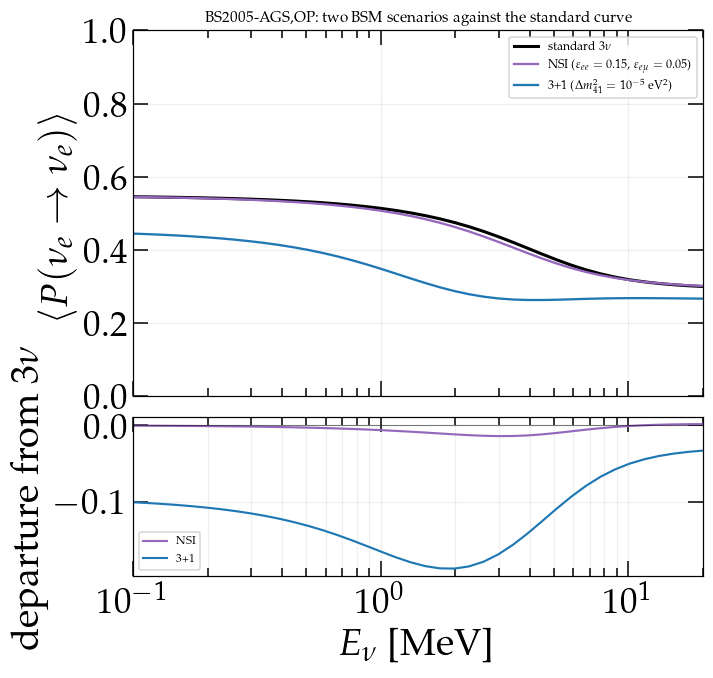

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(6.6, 6.0), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.3, 1.0], hspace=0.08))
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_std_bsm, lw=2.0, color='k',
               label=r'standard 3$\nu$')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm, lw=1.5, color='C4',
               label=r'NSI  ($\varepsilon_{ee}=0.15$, $\varepsilon_{e\mu}=0.05$)')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm, lw=1.5, color='C0',
               label=r'3+1  ($\Delta m^2_{41} = 10^{-5}$ eV$^2$)')
ax[0].set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
ax[0].set_title('BS2005-AGS,OP: two BSM scenarios against the standard curve',
                fontsize=10)
ax[0].grid(True, alpha=0.2)
ax[0].legend(fontsize=8)
ax[0].set_ylim(0.0, 1.0)

ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm - P_std_bsm, lw=1.4, color='C4',
               label='NSI')
ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm - P_std_bsm, lw=1.4, color='C0',
               label='3+1')
ax[1].axhline(0.0, color='k', lw=0.7, alpha=0.5)
ax[1].set_xlabel(r'$E_\nu$ [MeV]')
ax[1].set_ylabel(r'departure from 3$\nu$')
ax[1].grid(True, which='both', alpha=0.2)
ax[1].legend(fontsize=7.6)
for a in ax:
    a.set_xlim(E_BSM[0]/gd.UNIT_MEV, E_BSM[-1]/gd.UNIT_MEV)
fig.savefig('../fig/solar_bsm.pdf', bbox_inches='tight')

**Where each effect lives is as informative as how big it is.** The sterile
departure is concentrated near the MSW transition, because that is where the extra level
crossing sits and where an additional state can rearrange which vacuum eigenstate the neutrino
emerges as. The NSI departure is broader and smaller: with these $\varepsilon$ it shifts the
resonance position rather than adding structure.

**And both are much smaller here than the same physics produces on a supernova shock.** The
identical $\varepsilon$ moves notebook 14's shock probability by 0.44 on average, against
roughly a hundredth of that here. The reason is the observable rather than the model: this
panel is **phase-averaged**, so everything entering through the phase integrates away and only
the change in the eigenvectors and level crossings survives. On the shock the quantity is an
instantaneous probability along a ray, and the phase term is the larger part of the effect.

That is worth carrying away from this notebook: **a BSM effect's size is a property of the
observable at least as much as of the model**, and a sensitivity estimate quoted without saying
which probability it refers to can be wrong by a factor of thirty.

---

**Previous:** [The strategy parameter](12_magnus_adiabatic_hybrid_strategy.ipynb)  
**Next:** [A supernova shock front](14_magnus_supernova_shock.ipynb) --- where the error stops being a phase and becomes an envelope  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)